Project root: /Users/mac/Desktop/DSS5104_Assignment2
Using device: cpu
PaySim features: 6
Features: ['is_high_risk_type', 'balance_diff_orig', 'orig_balance_zero', 'amt_to_balance_ratio', 'orig_tx_count', 'orig_amt_mean']

Train shape: (5090096, 17)
Test shape: (1272524, 17)
Train fraud rate: 0.000778
Test fraud rate: 0.003343

Original X_train shape: (5090096, 6)
Sampled to 100,000 samples for faster training
X_train shape after scaling: (100000, 6)
X_test shape after scaling: (1272524, 6)

Training set size: 80,000
Validation set size: 20,000
Input dimension: 6

Training Supervised Neural Network on PaySim
Epoch 10/50, Train Loss: 0.0104, Val Loss: 0.0083
Epoch 20/50, Train Loss: 0.0050, Val Loss: 0.0035
Epoch 30/50, Train Loss: 0.0033, Val Loss: 0.0022
Epoch 40/50, Train Loss: 0.0026, Val Loss: 0.0017
Epoch 50/50, Train Loss: 0.0022, Val Loss: 0.0014

Test Results on PaySim:
  AUPRC: 0.9710
  ROC AUC: 0.9783

Cost-Sensitive Evaluation on PaySim (FN=$500, FP=$2)

Supervised Neural Ne

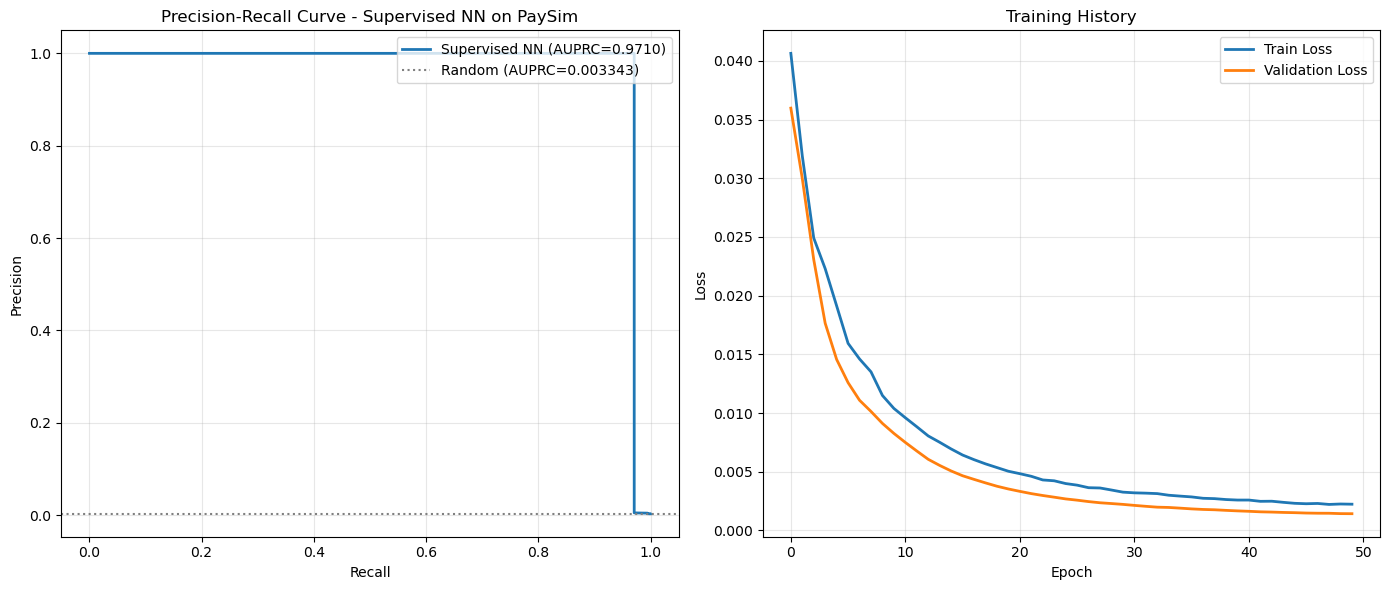


Results Summary - Supervised Neural Network on PaySim
                    Model    AUPRC  ROC AUC Cost-Optimal Threshold Min Total Cost Precision@Optimal Recall@Optimal F1@Optimal
Supervised Neural Network 0.970981 0.978296                 0.1634     $62,000.00            1.0000         0.9709     0.9852

✅ Supervised Neural Network on PaySim complete!


In [1]:
# Supervised Deep Learning for PaySim Fraud Detection
# Neural Network Classifier on Secondary Dataset

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)

# Set project root
try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_paysim_data():
    """Load PaySim data from processed folder"""
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    
    train = pd.read_parquet(data_dir / 'paysim_train.parquet')
    test = pd.read_parquet(data_dir / 'paysim_test.parquet')
    
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    
    features = info['paysim']['engineered_features']
    
    return train, test, features

# Load PaySim data
train_paysim, test_paysim, paysim_features = load_paysim_data()

print(f"PaySim features: {len(paysim_features)}")
print(f"Features: {paysim_features}")
print(f"\nTrain shape: {train_paysim.shape}")
print(f"Test shape: {test_paysim.shape}")
print(f"Train fraud rate: {train_paysim['isFraud'].mean():.6f}")
print(f"Test fraud rate: {test_paysim['isFraud'].mean():.6f}")

# ============================================================
# 1. Feature Preparation (with sampling for speed)
# ============================================================

X_train_raw = train_paysim[paysim_features].values
X_test_raw = test_paysim[paysim_features].values
y_train = train_paysim['isFraud'].values
y_test = test_paysim['isFraud'].values

print(f"\nOriginal X_train shape: {X_train_raw.shape}")

# Sample to reduce training time
SAMPLE_SIZE = 100000
if len(X_train_raw) > SAMPLE_SIZE:
    idx = np.random.choice(len(X_train_raw), SAMPLE_SIZE, replace=False)
    X_train_raw = X_train_raw[idx]
    y_train = y_train[idx]
    print(f"Sampled to {SAMPLE_SIZE:,} samples for faster training")

# Handle missing values
if np.isnan(X_train_raw).sum() > 0:
    print(f"Filling {np.isnan(X_train_raw).sum()} missing values...")
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape after scaling: {X_train.shape}")
print(f"X_test shape after scaling: {X_test.shape}")

# ============================================================
# 2. Define Model (simpler for PaySim)
# ============================================================

class FraudDetectionNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32, 16], dropout_rate=0.3):
        super(FraudDetectionNet, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        bce_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
        p_t = inputs * targets + (1 - inputs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        alpha_weight = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_weight * focal_weight * bce_loss
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

# ============================================================
# 3. Training Function
# ============================================================

def train_model(X_train, y_train, X_val, y_val, input_dim,
                epochs=50, batch_size=8192, lr=0.001,
                patience=10, verbose=True):
    
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.FloatTensor(y_val).to(device)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    model = FraudDetectionNet(input_dim).to(device)
    
    # Use Focal Loss for imbalance
    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)
        
        epoch_train_loss /= len(X_train)
        train_losses.append(epoch_train_loss)
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor).squeeze()
            val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

# ============================================================
# 4. Train Model
# ============================================================

# Split validation set (keep temporal order, use last 20% as validation)
val_size = int(len(X_train) * 0.2)
X_train_sub = X_train[:-val_size]
y_train_sub = y_train[:-val_size]
X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

print(f"\nTraining set size: {len(X_train_sub):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"Input dimension: {X_train.shape[1]}")

print("\n" + "="*60)
print("Training Supervised Neural Network on PaySim")
print("="*60)

model, train_losses, val_losses = train_model(
    X_train_sub, y_train_sub, X_val, y_val,
    input_dim=X_train.shape[1],
    epochs=50,
    batch_size=8192,
    lr=0.001,
    patience=10,
    verbose=True
)

# ============================================================
# 5. Predict and Basic Metrics
# ============================================================

X_test_tensor = torch.FloatTensor(X_test).to(device)
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_tensor).squeeze().cpu().numpy()

auprc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest Results on PaySim:")
print(f"  AUPRC: {auprc:.4f}")
print(f"  ROC AUC: {roc_auc:.4f}")

# ============================================================
# 6. Cost-Sensitive Evaluation
# ============================================================

def find_cost_optimal_threshold(y_true, y_scores, fn_cost=500, fp_cost=2):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    costs = []
    f1_scores = []
    
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        total_cost = fn * fn_cost + fp * fp_cost
        costs.append(total_cost)
        p = tp / (tp + fp + 1e-9)
        r = tp / (tp + fn + 1e-9)
        f1_scores.append(2 * p * r / (p + r + 1e-9) if (p + r) > 0 else 0)
    
    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    min_cost = costs[best_idx]
    f1_best_idx = np.argmax(f1_scores)
    f1_optimal_threshold = thresholds[f1_best_idx]
    
    return best_threshold, min_cost, f1_optimal_threshold, thresholds, costs, f1_scores

cost_threshold, min_cost, f1_threshold, thresholds, costs, f1_scores = find_cost_optimal_threshold(
    y_test, y_pred_proba, fn_cost=500, fp_cost=2
)

print("\n" + "="*60)
print("Cost-Sensitive Evaluation on PaySim (FN=$500, FP=$2)")
print("="*60)
print(f"\nSupervised Neural Network:")
print(f"  Cost-optimal threshold: {cost_threshold:.4f}")
print(f"  F1-optimal threshold: {f1_threshold:.4f}")
print(f"  Minimum total cost: ${min_cost:,.2f}")

# ============================================================
# 7. Evaluation at Cost-Optimal Threshold
# ============================================================

y_pred_optimal = (y_pred_proba >= cost_threshold).astype(int)

precision_opt = precision_score(y_test, y_pred_optimal)
recall_opt = recall_score(y_test, y_pred_optimal)
f1_opt = f1_score(y_test, y_pred_optimal)

print("\n" + "="*60)
print(f"Evaluation at Cost-Optimal Threshold ({cost_threshold:.4f}) on PaySim")
print("="*60)
print(f"  AUPRC: {auprc:.4f}")
print(f"  Precision: {precision_opt:.4f}")
print(f"  Recall: {recall_opt:.4f}")
print(f"  F1: {f1_opt:.4f}")

# ============================================================
# 8. Error Analysis (False Positives & False Negatives)
# ============================================================

print("\n" + "="*60)
print("Error Analysis on PaySim")
print("="*60)

fp_idx = np.where((y_test == 0) & (y_pred_optimal == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred_optimal == 0))[0]
tp_idx = np.where((y_test == 1) & (y_pred_optimal == 1))[0]

print(f"False Positives (Normal flagged as Fraud): {len(fp_idx)}")
print(f"False Negatives (Fraud missed): {len(fn_idx)}")
print(f"True Positives (Fraud caught): {len(tp_idx)}")

print("\n--- False Positives Analysis (First 10 samples) ---")
if len(fp_idx) > 0:
    sample_fp = test_paysim.iloc[fp_idx[:min(10, len(fp_idx))]]
    if 'amount' in sample_fp.columns:
        print(f"Transaction amounts: min=${sample_fp['amount'].min():.2f}, "
              f"max=${sample_fp['amount'].max():.2f}, "
              f"mean=${sample_fp['amount'].mean():.2f}")

print("\n--- False Negatives Analysis (First 10 samples) ---")
if len(fn_idx) > 0:
    sample_fn = test_paysim.iloc[fn_idx[:min(10, len(fn_idx))]]
    if 'amount' in sample_fn.columns:
        print(f"Transaction amounts: min=${sample_fn['amount'].min():.2f}, "
              f"max=${sample_fn['amount'].max():.2f}, "
              f"mean=${sample_fn['amount'].mean():.2f}")

# ============================================================
# 9. Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PR Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
axes[0].plot(recall_curve, precision_curve, linewidth=2, 
             label=f'Supervised NN (AUPRC={auprc:.4f})')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
                label=f'Random (AUPRC={y_test.mean():.6f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - Supervised NN on PaySim')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Training Curves
axes[1].plot(train_losses, label='Train Loss', linewidth=2)
axes[1].plot(val_losses, label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training History')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'supervised_nn_paysim_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 10. Save Results
# ============================================================

results_dir = PROJECT_ROOT / 'data/processed/dl_results'
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    'y_true': y_test,
    'supervised_nn_score': y_pred_proba
}).to_csv(results_dir / 'supervised_dl_scores_paysim.csv', index=False)

results_summary = pd.DataFrame({
    'Model': ['Supervised Neural Network'],
    'AUPRC': [auprc],
    'ROC AUC': [roc_auc],
    'Cost-Optimal Threshold': [f"{cost_threshold:.4f}"],
    'Min Total Cost': [f"${min_cost:,.2f}"],
    'Precision@Optimal': [f"{precision_opt:.4f}"],
    'Recall@Optimal': [f"{recall_opt:.4f}"],
    'F1@Optimal': [f"{f1_opt:.4f}"]
})

print("\n" + "="*60)
print("Results Summary - Supervised Neural Network on PaySim")
print("="*60)
print(results_summary.to_string(index=False))
